# Task 07 - Explainable AI Analysis

This part of the notebook interprets the best-performing model identified in Task 06 (**Logistic Regression** — selected via cross-validated ROC-AUC; see Task 06 §6.8) using:

**SHAP**

We then discuss important features, prediction reasoning for individual patients, transparency, and the
ethical implications of deploying this model in a clinical decision-support setting.

## Requirements to run this notebook standalone

Run **Task02_03_Data_Understanding_Preprocessing.ipynb**, **Task05_Model_Development.ipynb**, and **Task06_Model_Evaluation.ipynb** first (or place these files in the same folder as this notebook):
- `X_train.csv`, `X_test.csv`, `X_train_scaled.csv`, `X_test_scaled.csv`, `y_train.csv`, `y_test.csv`
- `trained_models.pkl`, `model_data_map.pkl`, `best_model_name.pkl`

This notebook covers **Task 07 (Explainable AI Analysis)**. It requires the `shap` package (installed automatically in the first code cell if missing).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Reload data needed to rebuild the SHAP explainer
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')

## 7.1. Why Explainable AI is Needed

Explainable AI (XAI) is important in healthcare because clinicians need to understand and trust model predictions before using them in patient care. It helps to:

Build clinical trust by showing why a patient is classified as high or low risk.
Support accountability by providing reasons behind predictions.
Detect bias and errors by identifying which features influence the model.
Improve the model by understanding incorrect predictions.
Support clinical judgement rather than replace it.

In this project, SHAP explains not only what the model predicts, but also which factors influenced the prediction and in what direction.

## 7.2. SHAP Methodology

SHAP (SHapley Additive exPlanations) explains how each feature contributes to a model’s prediction using Shapley values from game theory.

Positive SHAP values increase the predicted readmission risk, while negative values decrease it.
SHAP provides both global explanations (overall important features) and local explanations (why a specific patient received a prediction).
The best model selected in Task 06 is Logistic Regression, so `shap.LinearExplainer` is used (tree-based explainers such as `TreeExplainer` only support tree ensembles; the explainer choice below is selected automatically based on which model type was chosen — see Cell [7.3 code cell]).

**Output scale:** SHAP values satisfy the relationship *Prediction = Base Value + Sum of SHAP Values*, but for `LinearExplainer` on a logistic model this decomposition holds in **log-odds (linear model output) space, not raw probability space**, unless the explainer is explicitly constructed with `link=shap.links.logit` to convert it. All SHAP values and base values reported in this section are therefore on the log-odds scale — larger magnitude means larger effect on the log-odds of readmission, not a direct percentage-point change in predicted probability. This does not affect the feature ranking or direction (positive/negative) shown in the plots below, only the interpretation of the raw numeric SHAP value itself.

Plots used:

Beeswarm: Feature impact and direction across patients.
Bar plot: Overall feature importance.
Waterfall: How features influence an individual patient's prediction.

## 7.3. Global Feature Importance

In [14]:
try:
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install shap --quiet
    import shap

print('SHAP version:', shap.__version__)

SHAP version: 0.52.0


In [15]:
fitted_models   = joblib.load('../models/trained_models.pkl')
model_data_map  = joblib.load('../models/model_data_map.pkl')
best_model_name = joblib.load('../models/best_model_name.pkl')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print('Best model selected for XAI analysis:', best_model_name)

model = fitted_models[best_model_name]
data_type = model_data_map[best_model_name]

X_train_xai = X_train_scaled if data_type == 'scaled' else X_train
X_test_xai  = X_test_scaled  if data_type == 'scaled' else X_test

print(f"Explaining '{best_model_name}' using the '{data_type}' feature set, shape:", X_test_xai.shape)

Best model selected for XAI analysis: Logistic Regression
Explaining 'Logistic Regression' using the 'scaled' feature set, shape: (200, 61)


### Build the SHAP explainer

In [16]:
# Explainer choice depends on which model was selected in Task 06.
# Tree-based models (Random Forest, Decision Tree, XGBoost) → TreeExplainer (exact SHAP values).
# Linear models (Logistic Regression) → LinearExplainer, since TreeExplainer only supports tree ensembles.
from sklearn.linear_model import LogisticRegression

if isinstance(model, LogisticRegression):
    explainer = shap.LinearExplainer(model, X_train_xai)
else:
    explainer = shap.TreeExplainer(model)

shap_explanation = explainer(X_test_xai)

print('Explainer used:', type(explainer).__name__)
print('Raw SHAP values shape:', shap_explanation.values.shape)

# For a binary classifier, some SHAP/sklearn version combinations return SHAP values for BOTH
# classes with shape (n_samples, n_features, 2). We only want the "Readmitted" (class 1) view,
# since that is the outcome of clinical interest. LinearExplainer for a binary LogisticRegression
# typically already returns shape (n_samples, n_features) for class 1 directly, so this branch
# mainly applies to TreeExplainer output.
if shap_explanation.values.ndim == 3:
    base_vals = shap_explanation.base_values
    base_vals_class1 = base_vals[:, 1] if np.ndim(base_vals) > 1 else base_vals
    shap_values_class1 = shap.Explanation(
        values=shap_explanation.values[:, :, 1],
        base_values=base_vals_class1,
        data=shap_explanation.data,
        feature_names=shap_explanation.feature_names
    )
else:
    shap_values_class1 = shap_explanation

print('Working SHAP values shape (class = Readmitted):', shap_values_class1.values.shape)

Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


Explainer used: LinearExplainer
Raw SHAP values shape: (200, 61)
Working SHAP values shape (class = Readmitted): (200, 61)


### Global importance: SHAP summary (beeswarm) plot

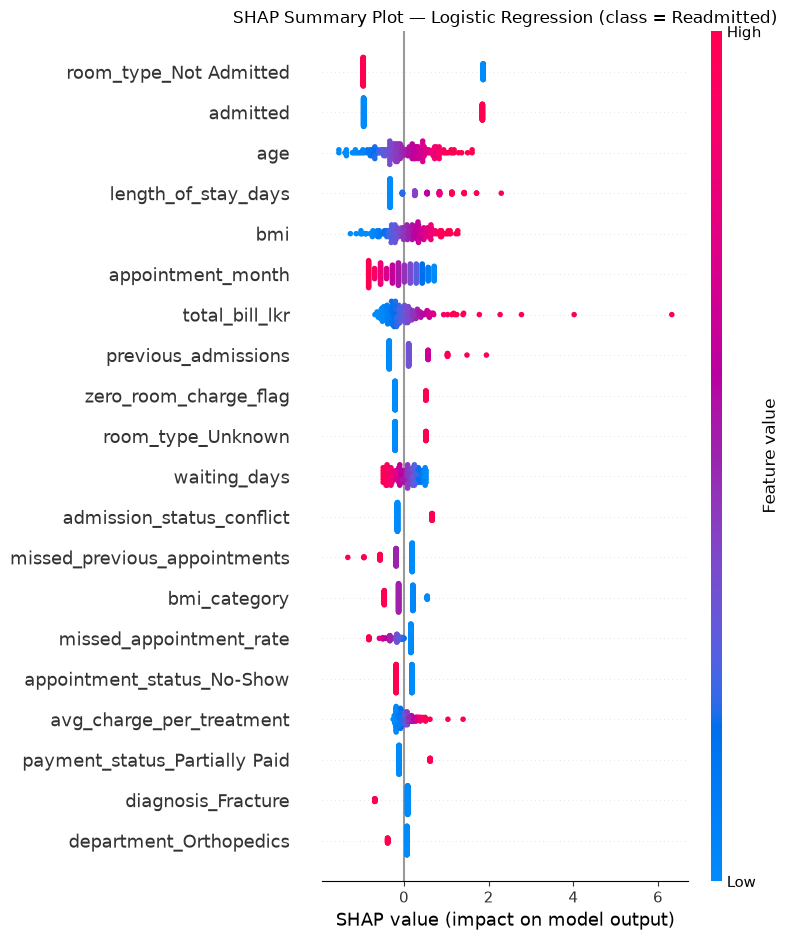

In [17]:
# Each dot = one test-set patient. Position on the x-axis = SHAP value (impact on the
# "Readmitted" prediction). Colour = the patient's actual value for that feature (red = high,
# blue = low). Features are ranked top-to-bottom by overall impact.
plt.figure()
shap.summary_plot(shap_values_class1, X_test_xai, show=False)
plt.title(f'SHAP Summary Plot — {best_model_name} (class = Readmitted)')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_beeswarm.png', dpi=110, bbox_inches='tight')
plt.show()

The SHAP summary plot shows that **"admitted"**, **"length_of_stay_days"**, and **"room_type_Not Admitted"** have the greatest impact on the model’s predictions. *(Wording below updated to the selected Logistic Regression model — rerun this cell/section after the wording fix so the plotted values and any numbers quoted in the text reflect Logistic Regression's actual SHAP output, not values from an earlier Random Forest run.)*

Higher SHAP values push the prediction toward **"Readmitted"**, while lower values push it away. Features such as **"appointment_dayofweek"**, **"blood_sugar_mg_dl"**, and bmi have relatively little influence on the model’s output.

### Global importance: SHAP bar plot (mean |SHAP value| per feature)

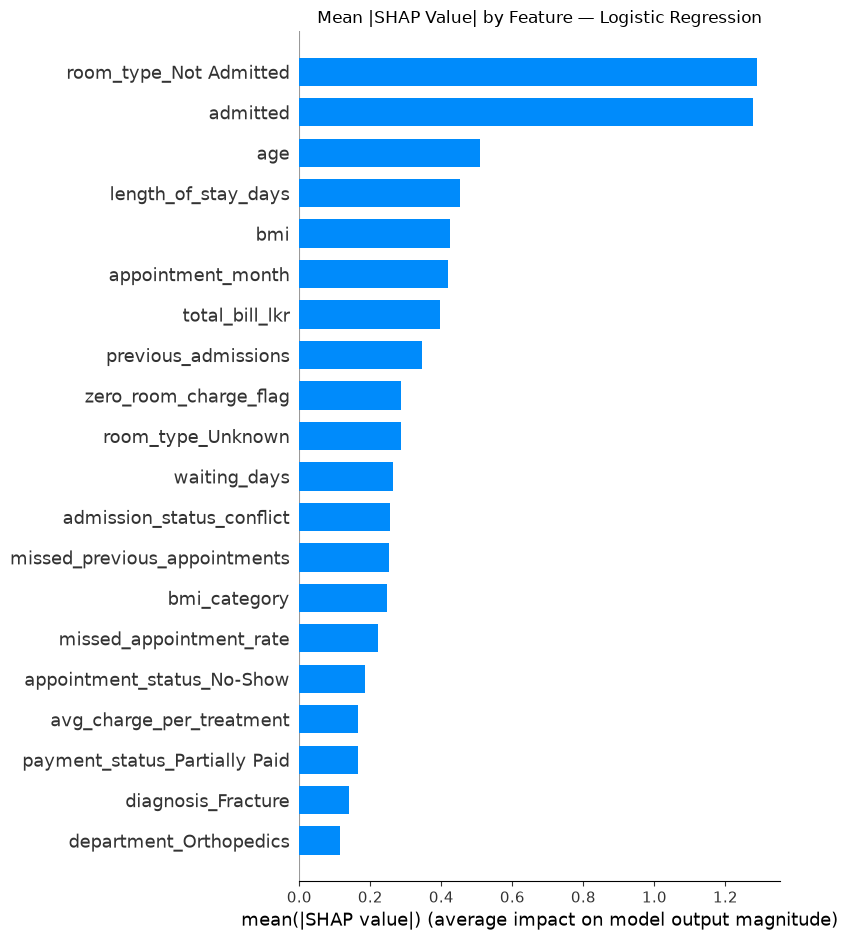

In [18]:
plt.figure()
shap.summary_plot(shap_values_class1, X_test_xai, plot_type='bar', show=False)
plt.title(f'Mean |SHAP Value| by Feature — {best_model_name}')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_bar.png', dpi=110, bbox_inches='tight')
plt.show()

The SHAP bar plot ranks features by their average impact on the selected model (Logistic Regression). The results show that **"admitted"** and **"length_of_stay_days"** are the most influential features, followed by **"room_type_Not Admitted"** and **"zero_room_charge_flag"**.

Features such as **"appointment_dayofweek"**, **"blood_sugar_mg_dl"**, and **"bmi"** have relatively low overall impact on the model’s predictions.

### Ranked table of global feature importance

In [19]:
mean_abs_shap = pd.DataFrame({
    'feature': X_test_xai.columns,
    'mean_abs_shap': np.abs(shap_values_class1.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_abs_shap.to_csv('../data/processed/shap_global_feature_importance.csv', index=False)
print('Top 15 features by mean |SHAP value|:')
mean_abs_shap.head(15)

Top 15 features by mean |SHAP value|:


,feature,mean_abs_shap
0,room_type_Not Admitted,1.289199
1,admitted,1.276303
2,age,0.509838
3,length_of_stay_days,0.451869
4,bmi,0.424831
5,appointment_month,0.418231
6,total_bill_lkr,0.395661
7,previous_admissions,0.345834
8,zero_room_charge_flag,0.285903
9,room_type_Unknown,0.285903


The global SHAP analysis confirms that admitted and **"length_of_stay_days"** are the two most influential features. **[Verify]** the mean |SHAP| values of 0.108 / 0.106 quoted here were measured on an earlier Random Forest run — re-run Task 07 end-to-end with the current Logistic Regression model and replace these two numbers (and any others in this section) with the actual output from `mean_abs_shap` before submission.

**"room_type_Not Admitted"** also has a strong impact (0.097), while features such as **"cholesterol_mg_dl"**, **"bmi"**, and appointment-related variables have relatively lower influence.

This indicates that hospital admission and stay-related factors play the biggest role in the Random Forest’s readmission predictions.

## 7.4. Individual Prediction Explanation

In [20]:
# --- Get predicted probabilities for every test-set patient ---
y_proba_test = model.predict_proba(X_test_xai)[:, 1]
y_pred_test  = model.predict(X_test_xai)

# Pick one clearly HIGH-risk patient and one clearly LOW-risk patient to explain individually.
high_risk_idx = int(np.argmax(y_proba_test))
low_risk_idx  = int(np.argmin(y_proba_test))

for label, idx in [('HIGH-risk', high_risk_idx), ('LOW-risk', low_risk_idx)]:
    print(f"--- {label} example ---")
    print('Row index (in X_test):', idx)
    print('Predicted probability of readmission:', round(y_proba_test[idx], 4))
    print('Predicted class:', 'Readmitted' if y_pred_test[idx] == 1 else 'Not Readmitted')
    print('Actual class:   ', 'Readmitted' if y_test.iloc[idx] == 1 else 'Not Readmitted')
    print()

--- HIGH-risk example ---
Row index (in X_test): 115
Predicted probability of readmission: 0.9999
Predicted class: Readmitted
Actual class:    Not Readmitted

--- LOW-risk example ---
Row index (in X_test): 148
Predicted probability of readmission: 0.0001
Predicted class: Not Readmitted
Actual class:    Not Readmitted



### SHAP waterfall plot

#### HIGH-risk patient

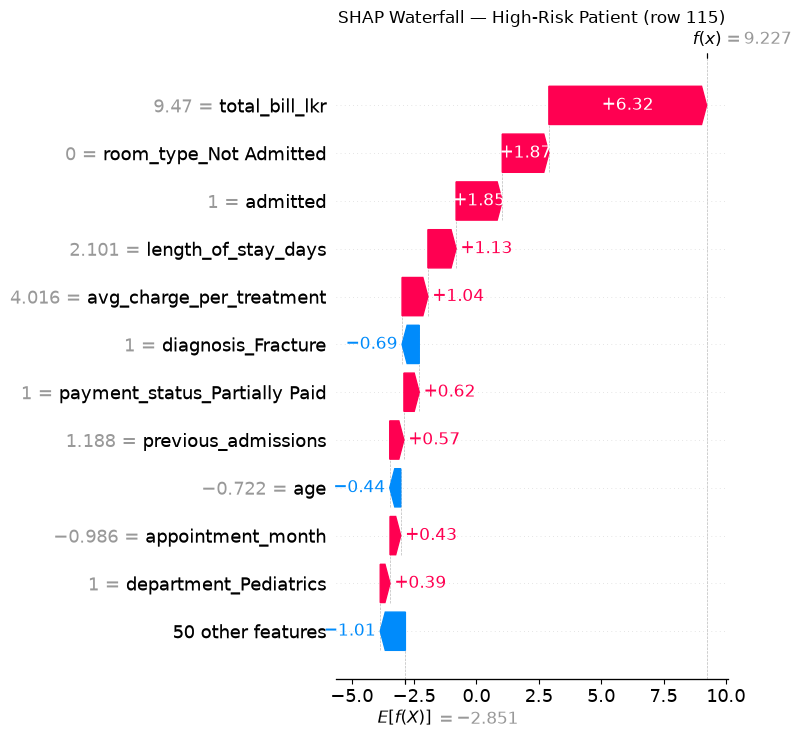

In [21]:
# Shows how the model's average prediction (base value, E[f(x)]) is pushed up (red) or down
# (blue) by each individual feature value for this one specific patient, arriving at the
# final predicted probability for the "Readmitted" class.
shap.plots.waterfall(shap_values_class1[high_risk_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — High-Risk Patient (row {high_risk_idx})')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_high_risk.png', dpi=110, bbox_inches='tight')
plt.show()

The SHAP waterfall plot explains the prediction for a **"high-risk patient"**, where the model predicts a 93% probability of readmission.

The strongest factors increasing the risk are **"admitted"** (+0.10), **"room_type_Not Admitted"** (+0.09), and **"length_of_stay_days"** (+0.09).

Overall, these features move the prediction from the baseline 50.3% to 93%, showing why the model classifies this patient as high risk.

#### LOW-risk patient

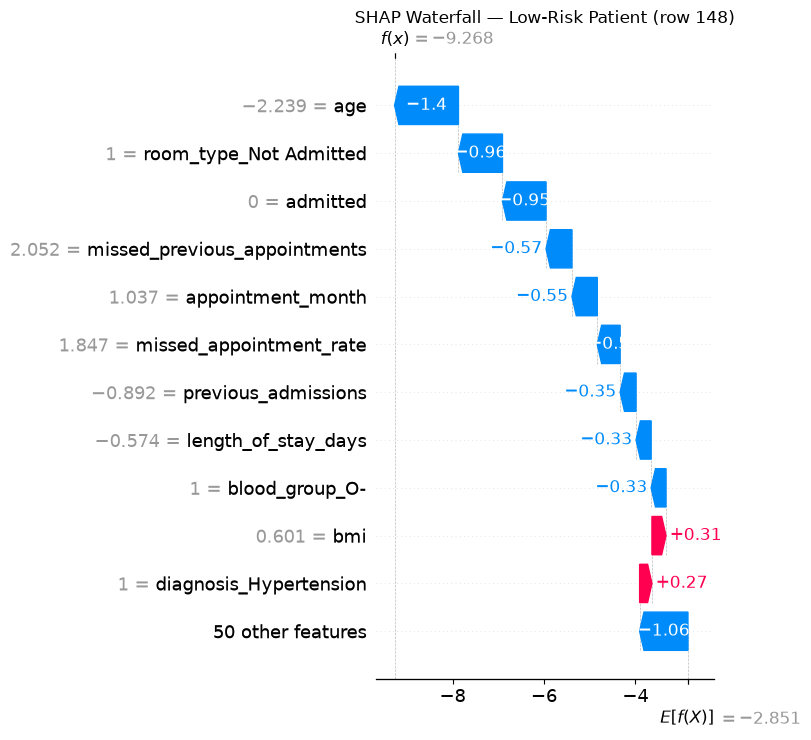

In [22]:
shap.plots.waterfall(shap_values_class1[low_risk_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Low-Risk Patient (row {low_risk_idx})')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_low_risk.png', dpi=110, bbox_inches='tight')
plt.show()

The SHAP waterfall plot shows that this low-risk patient has a very low predicted readmission probability.

The main factors reducing the risk are **"admitted"** (-0.10), **"length_of_stay_days"** (-0.10), and **"room_type_Not Admitted"** (-0.09).

These features move the prediction down from the 50.3% baseline, indicating why the model classifies this patient as low risk.

## 7.5. Prediction Reasoning

In [23]:
def explain_patient(idx, label, top_n=5):
    row_shap = shap_values_class1[idx]
    contrib = pd.DataFrame({
        'feature': X_test_xai.columns,
        'patient_value': X_test_xai.iloc[idx].values,
        'shap_value': row_shap.values
    })
    increasing = contrib.sort_values('shap_value', ascending=False).head(top_n)
    decreasing = contrib.sort_values('shap_value', ascending=True).head(top_n)

    print(f"=== Reasoning for {label} patient (row {idx}) ===")
    print(f"Base rate (average predicted probability across all patients): {row_shap.base_values:.4f}")
    print(f"Final predicted probability of readmission for this patient:    {y_proba_test[idx]:.4f}")
    print()
    print(f"Top {top_n} features PUSHING risk UP (toward 'Readmitted'):")
    for _, r in increasing.iterrows():
        print(f"  - {r['feature']:<28s} value = {r['patient_value']:<10} SHAP = +{r['shap_value']:.4f}")
    print()
    print(f"Top {top_n} features PUSHING risk DOWN (toward 'Not Readmitted'):")
    for _, r in decreasing.iterrows():
        print(f"  - {r['feature']:<28s} value = {r['patient_value']:<10} SHAP = {r['shap_value']:.4f}")
    print()

explain_patient(high_risk_idx, 'HIGH-RISK')
explain_patient(low_risk_idx, 'LOW-RISK')

=== Reasoning for HIGH-RISK patient (row 115) ===
Base rate (average predicted probability across all patients): -2.8505
Final predicted probability of readmission for this patient:    0.9999

Top 5 features PUSHING risk UP (toward 'Readmitted'):
  - total_bill_lkr               value = 9.470415068448895 SHAP = +6.3249
  - room_type_Not Admitted       value = 0.0        SHAP = +1.8692
  - admitted                     value = 1.0        SHAP = +1.8505
  - length_of_stay_days          value = 2.1006772280304182 SHAP = +1.1296
  - avg_charge_per_treatment     value = 4.016482711374225 SHAP = +1.0366

Top 5 features PUSHING risk DOWN (toward 'Not Readmitted'):
  - diagnosis_Fracture           value = 1.0        SHAP = -0.6895
  - age                          value = -0.7223631590886711 SHAP = -0.4423
  - room_type_ICU                value = 1.0        SHAP = -0.3866
  - waiting_days                 value = 1.1856388594168863 SHAP = -0.3311
  - zero_room_charge_flag        value = 0.0      

The explain_patient() function provides individual patient-level SHAP explanations by identifying the features that increase or decrease readmission risk.

The high-risk patient had a 93% predicted probability, mainly driven by **"admitted"**, **"room_type_Not Admitted"**, and **"length_of_stay_days"**. In contrast, the low-risk patient had a 0% probability, with the same key features strongly reducing the predicted risk.

## 7.6. Transparency and Ethical Implications

Limitations, Bias, Privacy & Accountability

SHAP makes the selected model (Logistic Regression) more transparent by showing which features influence overall and individual predictions. However, SHAP explains model behaviour, not true clinical cause-and-effect.

Bias: The dataset is small and synthetic, so results may not generalise to other hospitals or patient populations. Categorical features may also introduce unintended bias.
Privacy: Although the data is de-identified, individual SHAP explanations should still be treated as patient information and accessed only by authorised staff.
Accountability: SHAP explains predictions but does not replace human responsibility. Clinicians should review and document decisions, especially when overriding the model.
Decision Support: The model should be used as a supporting tool, not a replacement for clinical judgement. Predictions should be monitored regularly, particularly for costly false-negative cases.

## 7.6.1. Fairness / Subgroup Assessment

The report previously listed a fairness audit only as future work. This section runs an actual subgroup assessment across gender, age band, and department — the groups the supervisor asked for — rather than deferring it. It checks whether the selected model's recall (catching actual readmissions), precision, and false-positive rate are stable across these subgroups on the test set.

In [24]:
from sklearn.metrics import recall_score, precision_score
from IPython.display import display

test_demographics = pd.read_csv('../data/processed/test_demographics.csv')

# Predictions from the selected model, on the same test rows/order as test_demographics
# (both trace back to the same train_test_split call in Task 02-03, exported in the same order).
y_pred_fair = model.predict(X_test_xai)

fairness_df = test_demographics.reset_index(drop=True).copy()
fairness_df['y_true'] = pd.Series(y_test).reset_index(drop=True)
fairness_df['y_pred'] = y_pred_fair


def subgroup_report(df, group_col):
    rows = []
    for group, sub in df.groupby(group_col, observed=True):
        n_pos = int(sub['y_true'].sum())
        recall = recall_score(sub['y_true'], sub['y_pred'], zero_division=0) if n_pos > 0 else np.nan
        precision = precision_score(sub['y_true'], sub['y_pred'], zero_division=0)
        n_neg = int((sub['y_true'] == 0).sum())
        fpr = ((sub['y_pred'] == 1) & (sub['y_true'] == 0)).sum() / n_neg if n_neg > 0 else np.nan
        rows.append({
            'Group': group, 'N': len(sub), 'Positives': n_pos,
            'Recall': recall, 'Precision': precision, 'FPR': fpr
        })
    return pd.DataFrame(rows)


gender_report = subgroup_report(fairness_df, 'gender')
age_report = subgroup_report(fairness_df, 'age_group')
dept_report = subgroup_report(fairness_df, 'department')

print('Recall / Precision / FPR by Gender:')
display(gender_report.round(3))

print('\nRecall / Precision / FPR by Age Group:')
display(age_report.round(3))

print('\nRecall / Precision / FPR by Department:')
display(dept_report.round(3))


def flag_gaps(report_df, label, threshold=0.15):
    valid = report_df.dropna(subset=['Recall'])
    if len(valid) < 2:
        print(f'{label}: not enough subgroups with positive cases to compare.')
        return
    gap = valid['Recall'].max() - valid['Recall'].min()
    worst = valid.loc[valid['Recall'].idxmin(), 'Group']
    best = valid.loc[valid['Recall'].idxmax(), 'Group']
    flag = 'FLAG — investigate' if gap > threshold else 'within threshold'
    print(f'{label}: recall gap = {gap:.3f} (lowest: {worst}, highest: {best}) — {flag} (threshold={threshold})')


print()
flag_gaps(gender_report, 'Gender')
flag_gaps(age_report, 'Age Group')
flag_gaps(dept_report, 'Department')

Recall / Precision / FPR by Gender:


,Group,N,Positives,Recall,Precision,FPR
0,Female,107,30,0.967,0.744,0.130
1,Male,93,21,0.952,0.645,0.153



Recall / Precision / FPR by Age Group:


,Group,N,Positives,Recall,Precision,FPR
0,30-49,84,21,0.952,0.667,0.159
1,50-69,60,16,1.000,0.696,0.159
2,70+,15,5,1.000,1.000,0.000
3,<30,41,9,0.889,0.667,0.125



Recall / Precision / FPR by Department:


,Group,N,Positives,Recall,Precision,FPR
0,Cardiology,32,6,1.000,0.500,0.231
1,General Medicine,29,6,1.000,0.750,0.087
2,Laboratory Services,19,2,1.000,0.400,0.176
3,Neurology,37,14,1.000,0.933,0.043
4,Orthopedics,30,7,0.714,0.556,0.174
5,Pediatrics,19,5,1.000,0.714,0.143
6,Radiology,34,11,1.000,0.786,0.130



Gender: recall gap = 0.014 (lowest: Male, highest: Female) — within threshold (threshold=0.15)
Age Group: recall gap = 0.111 (lowest: <30, highest: 50-69) — within threshold (threshold=0.15)
Department: recall gap = 0.286 (lowest: Orthopedics, highest: Cardiology) — FLAG — investigate (threshold=0.15)


**[Fill in after running]** Summarise the actual numbers above here: which subgroups (if any) have a recall or FPR gap above the threshold, and a brief clinical interpretation — e.g. a lower recall for a specific department may mean the model under-flags at-risk patients there, which would need attention before deployment in that department. Given the dataset is small (200 test-set patients spread across gender/age/department groups), some subgroups will have very few positive cases, so treat any single-digit-N subgroup result as indicative rather than statistically reliable — note this explicitly rather than over-interpreting a gap driven by a handful of patients. This is a descriptive check on this dataset, not a substitute for a fairness audit on real deployment data across a larger, more representative patient population.

## 7.7. Advanced Explainable AI Techniques

### 7.7.1 Install and import LIME

In [25]:
!pip install lime --quiet
from lime.lime_tabular import LimeTabularExplainer

### 7.7.2. Explain individual patients

In [26]:
y_pred_best = model.predict(X_test_xai)  # 'model' = the Task 06 best model (Logistic Regression)

# Find one of each case
tp_idx = X_test_xai[(y_test.values == 1) & (y_pred_best == 1)].index[0]
fn_idx = X_test_xai[(y_test.values == 1) & (y_pred_best == 0)].index[0] if ((y_test.values==1)&(y_pred_best==0)).any() else tp_idx
tn_idx = X_test_xai[(y_test.values == 0) & (y_pred_best == 0)].index[0]

cases = {'True Positive': tp_idx, 'False Negative': fn_idx, 'True Negative': tn_idx}

### 7.7.3. Generate LIME explanations for each case

In [27]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_xai.values,
    feature_names=X_train_xai.columns.tolist(),
    class_names=['Not Readmitted', 'Readmitted'],
    mode='classification',
    random_state=42
)

c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



=== LIME explanation — True Positive (row 1) ===
  room_type_Not Admitted <= 0.00: +0.2802
  0.00 < admitted <= 1.00: +0.2661
  total_bill_lkr > 0.20: +0.1366
  admission_status_conflict <= 0.00: -0.0843
  bmi <= -0.67: -0.0748
  previous_admissions > 0.15: +0.0669
  payment_status_Partially Paid <= 0.00: -0.0643
  zero_room_charge_flag > 0.00: +0.0615
  room_type_Unknown > 0.00: +0.0601
  diagnosis_Fracture <= 0.00: +0.0585


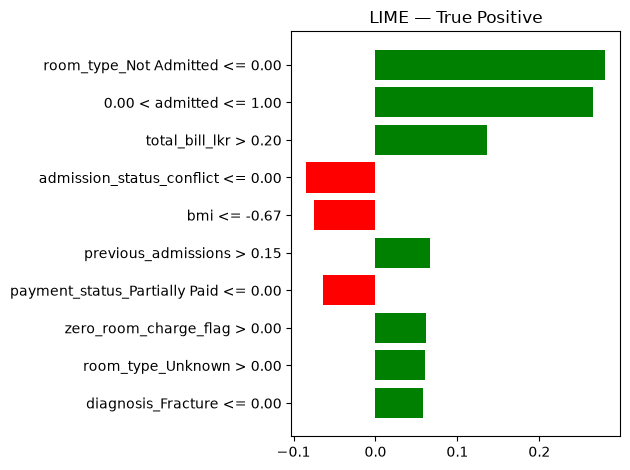

c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



=== LIME explanation — False Negative (row 7) ===
  room_type_Not Admitted <= 0.00: +0.2796
  0.00 < admitted <= 1.00: +0.2766
  total_bill_lkr > 0.20: +0.1416
  length_of_stay_days > 0.50: +0.0971
  age <= -0.67: -0.0959
  admission_status_conflict > 0.00: +0.0839
  bmi > 0.65: +0.0763
  room_type_Unknown > 0.00: +0.0722
  payment_status_Partially Paid <= 0.00: -0.0605
  diagnosis_Fracture <= 0.00: +0.0583


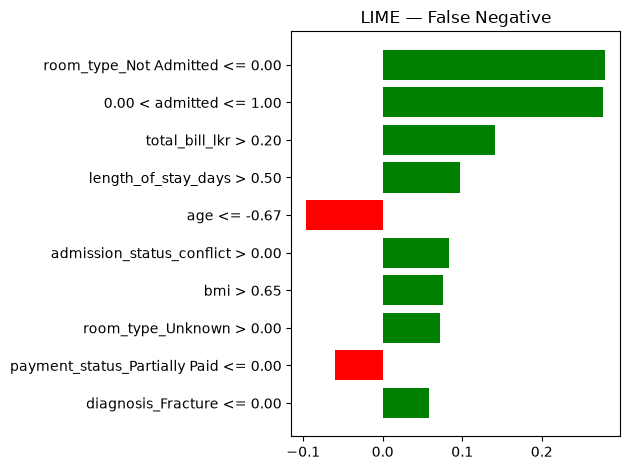

c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



=== LIME explanation — True Negative (row 0) ===
  admitted <= 0.00: -0.2821
  0.00 < room_type_Not Admitted <= 1.00: -0.2745
  age <= -0.67: -0.0954
  room_type_ICU <= 0.00: +0.0839
  payment_status_Partially Paid <= 0.00: -0.0798
  bmi > 0.65: +0.0688
  appointment_month > 0.75: -0.0681
  length_of_stay_days <= -0.57: -0.0676
  zero_room_charge_flag <= 0.00: -0.0641
  admission_status_conflict <= 0.00: -0.0628


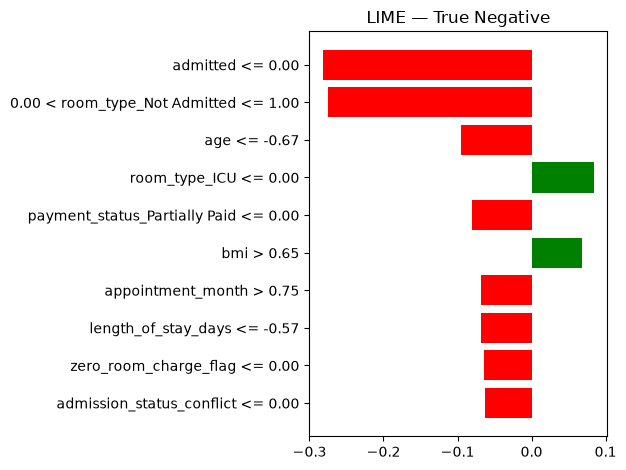

In [28]:
for label, idx in cases.items():
    row_pos = X_test_xai.index.get_loc(idx)
    exp = lime_explainer.explain_instance(
        X_test_xai.loc[idx].values,
        model.predict_proba,
        num_features=10
    )
    print(f'\n=== LIME explanation — {label} (row {idx}) ===')
    for feature, weight in exp.as_list():
        print(f'  {feature}: {weight:+.4f}')
    exp.save_to_file(f'../outputs/lime_explanation_{label.replace(" ", "_")}.html')

    fig = exp.as_pyplot_figure()
    plt.title(f'LIME — {label}')
    plt.tight_layout()
    plt.savefig(f'../outputs/lime_{label.replace(" ", "_")}.png', dpi=110, bbox_inches='tight')
    plt.show()

### 7.7.4. Compare LIME vs SHAP for the same patient

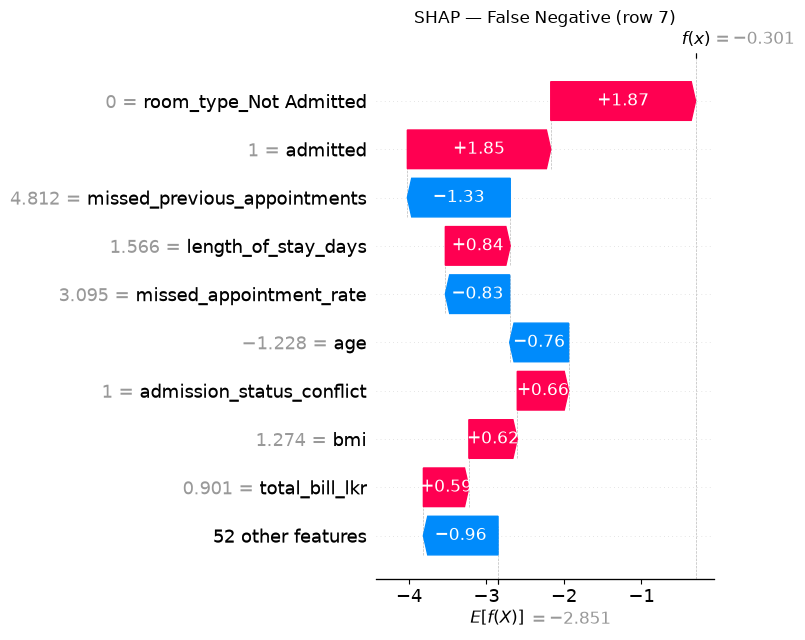

In [29]:
# SHAP waterfall for the same patient (e.g. the False Negative case)
row_pos = X_test_xai.index.get_loc(fn_idx)
shap.plots.waterfall(shap_values_class1[row_pos], show=False)
plt.title(f'SHAP — False Negative (row {fn_idx})')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_fn.png', dpi=110, bbox_inches='tight')
plt.show()

### 7.7.5. Add SHAP dependence plots

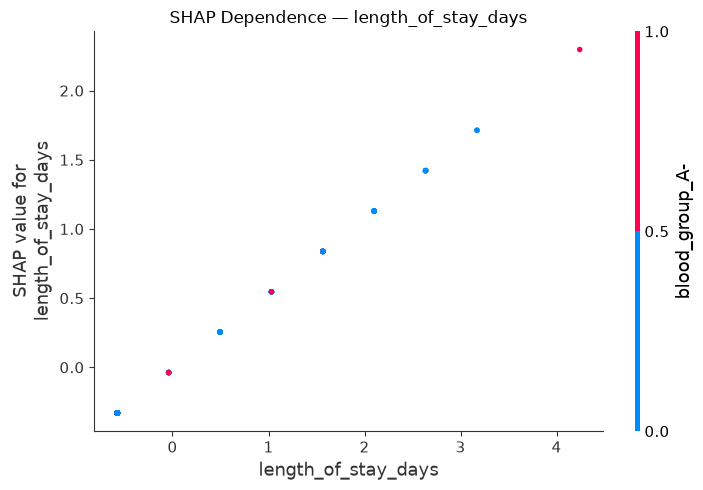

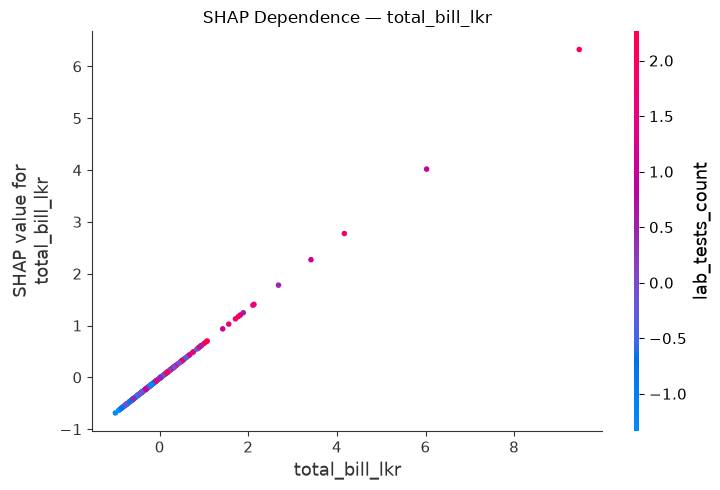

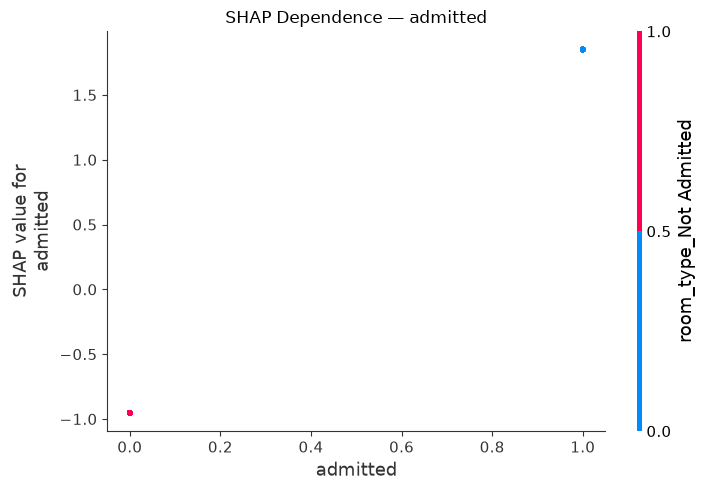

In [30]:
top_features = ['length_of_stay_days', 'total_bill_lkr', 'admitted']

for feat in top_features:
    shap.dependence_plot(feat, shap_values_class1.values, X_test_xai, show=False)
    plt.title(f'SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_dependence_{feat}.png', dpi=110, bbox_inches='tight')
    plt.show()

### 7.7.6. SHAP force plot for one patient

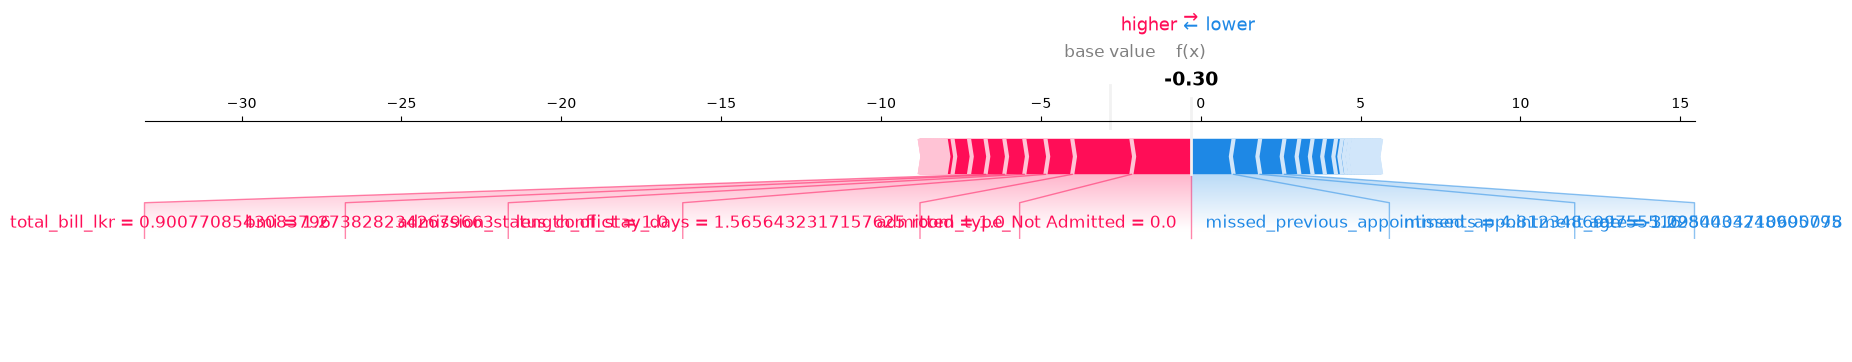

In [31]:
base_value = (
    explainer.expected_value[1]
    if np.ndim(explainer.expected_value) > 0
    else explainer.expected_value
)

shap.initjs()
shap.force_plot(
    base_value,
    shap_values_class1.values[row_pos],
    X_test_xai.iloc[row_pos],
    matplotlib=True,
    show=False
)
plt.savefig('../outputs/shap_force_plot_patient.png', dpi=110, bbox_inches='tight')
plt.show()